In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

print(f"Device : {device}")
print(f"Seed   : {SEED}")

Device : cuda
Seed   : 42


In [2]:
# ImageNet normalisation — consistent across all three models
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder('augmented_dataset/train', transform=transform)
val_dataset   = datasets.ImageFolder('augmented_dataset/val',   transform=transform)
test_dataset  = datasets.ImageFolder('augmented_dataset/test',  transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train : {len(train_dataset)} images")
print(f"Val   : {len(val_dataset)} images")
print(f"Test  : {len(test_dataset)} images")
print(f"Classes: {train_dataset.classes}")

Train : 13569 images
Val   : 959 images
Test  : 962 images
Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [3]:
# Class weights computed from train only
train_labels  = [label for _, label in train_dataset.samples]
class_counts  = np.bincount(train_labels)
print(f"Train class distribution: {dict(zip(train_dataset.classes, class_counts))}")

class_weights = 1.0 / (torch.tensor(class_counts, dtype=torch.float) + 1e-5)
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = class_weights.to(device)
print(f"Loss weights: {class_weights.cpu().numpy().round(4)}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

Train class distribution: {'MildDemented': np.int64(1881), 'ModerateDemented': np.int64(264), 'NonDemented': np.int64(6720), 'VeryMildDemented': np.int64(4704)}
Loss weights: [0.4543 3.2369 0.1272 0.1817]


In [4]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1   = nn.Conv2d(3,  16, kernel_size=3, padding=1)
        self.conv2   = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3   = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool    = nn.MaxPool2d(2, 2)
        self.fc1     = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

model_cnn = BaselineCNN().to(device)
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

total_params = sum(p.numel() for p in model_cnn.parameters())
print(f"Parameters: {total_params:,}")
print(f"Model loaded on: {device}")

Parameters: 6,446,756
Model loaded on: cuda


In [5]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, save_path, scheduler=None):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')

    # Scaler for Mixed Precision
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(1, epochs + 1):
        start = time.time()

        # --- Training ---
        model.train()
        train_loss, train_correct = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            # Autocast enabling Tensor Cores
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Scaled Backpropagation
            scaler.scale(loss).backward()
            
            # Gradient Clipping to Prevent Spikes
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # Weight Update
            scaler.step(optimizer)
            scaler.update()

            train_loss    += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_acc  = train_correct / len(train_loader.dataset)

        # --- Validation ---
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc  = val_correct / len(val_loader.dataset)

        # --- Checkpoint ---
        checkpoint_msg = ''
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)
            checkpoint_msg = '  ← best'

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        vram_used = torch.cuda.memory_allocated() / 1e9 if torch.cuda.is_available() else 0
        elapsed = time.time() - start
        print(f"Epoch {epoch:2d}/{epochs} | {int(elapsed//60)}m {int(elapsed%60)}s | "
              f"Train loss {epoch_train_loss:.4f} acc {epoch_train_acc:.4f} | "
              f"Val loss {epoch_val_loss:.4f} acc {epoch_val_acc:.4f} | "
              f"VRAM {vram_used:.2f}GB{checkpoint_msg}")
        
        if scheduler is not None:
            scheduler.step(epoch_val_loss)

    # Load best weights before returning
    model.load_state_dict(torch.load(save_path))
    print(f"\nBest val loss: {best_val_loss:.4f} — weights loaded from '{save_path}'")
    return history

In [6]:
print("Starting training...")
history_cnn = train_model(
    model_cnn, train_loader, val_loader, criterion, optimizer,
    epochs=30, save_path='baseline_cnn.pth'
)

Starting training...
Epoch  1/30 | 0m 36s | Train loss 1.4263 acc 0.4401 | Val loss 0.9011 acc 0.5589 | VRAM 0.13GB  ← best
Epoch  2/30 | 0m 37s | Train loss 1.0340 acc 0.5205 | Val loss 0.7889 acc 0.5766 | VRAM 0.13GB  ← best
Epoch  3/30 | 0m 37s | Train loss 0.7980 acc 0.5745 | Val loss 0.7302 acc 0.6152 | VRAM 0.13GB  ← best
Epoch  4/30 | 0m 37s | Train loss 0.6738 acc 0.6173 | Val loss 0.6620 acc 0.6715 | VRAM 0.13GB  ← best
Epoch  5/30 | 0m 38s | Train loss 0.5958 acc 0.6648 | Val loss 0.5239 acc 0.7383 | VRAM 0.13GB  ← best
Epoch  6/30 | 0m 38s | Train loss 0.5237 acc 0.7037 | Val loss 0.4364 acc 0.7914 | VRAM 0.13GB  ← best
Epoch  7/30 | 0m 37s | Train loss 0.4745 acc 0.7314 | Val loss 0.4495 acc 0.8040 | VRAM 0.13GB
Epoch  8/30 | 0m 37s | Train loss 0.4500 acc 0.7593 | Val loss 0.3956 acc 0.8102 | VRAM 0.13GB  ← best
Epoch  9/30 | 0m 36s | Train loss 0.4075 acc 0.7821 | Val loss 0.3340 acc 0.8530 | VRAM 0.13GB  ← best
Epoch 10/30 | 0m 37s | Train loss 0.3829 acc 0.7998 | Val lo

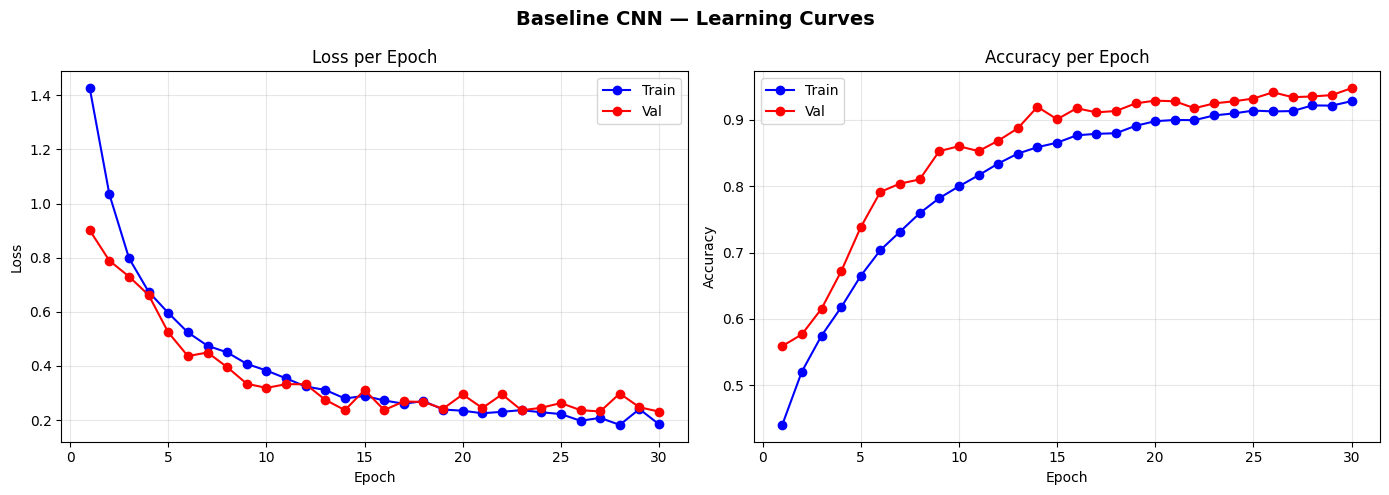

Saved: baseline_cnn_curves.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline CNN — Learning Curves', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history_cnn['train_loss']) + 1)

axes[0].plot(epochs_range, history_cnn['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_range, history_cnn['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_cnn['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs_range, history_cnn['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: baseline_cnn_curves.png")